# Loudspeaker Price Analysis - LOT 2: EDA & Feature Analysis

Exploratory analysis focused on the price target and its relationship with key T/S parameters and categorical features.


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')


## 1. Data loading


In [64]:
data_path = '../Datas/speaker_db_selected_refined.csv'
df = pd.read_csv(data_path)
df = df.drop(columns=["row_id"])
df = df.drop(columns=["spec_general_reference"])
df.head()



,price,spec_general_marque,spec_general_type_produit,spec_informations_impedance_nominale,spec_forme_materiaux_systeme_magnetique,spec_forme_materiaux_forme_facade,spec_parametres_petits_signaux_qts,spec_parametres_petits_signaux_qes,spec_parametres_petits_signaux_qms,spec_forme_materiaux_materiau_saladier,spec_forme_materiaux_materiau_suspension,spec_forme_materiaux_support_bobine,spec_forme_materiaux_fil_bobine,spec_forme_materiaux_materiau_dome,spec_informations_puissance_nominale_w,spec_informations_sensibilite_fabricant_db,spec_parametres_petits_signaux_fs_hz,spec_donnees_poids_kg,spec_parametres_fondamentaux_re_ohm,spec_donnees_xmax_mm,spec_parametres_fondamentaux_mms_gr,spec_donnees_ebp_hz,spec_parametres_petits_signaux_vas_l,spec_donnees_rendement_calcule_pct,spec_parametres_fondamentaux_le_mh,spec_parametres_fondamentaux_sd_cm2,spec_parametres_fondamentaux_bl_t_m,spec_dimensions_diametre_systeme_magnetique_mm,spec_informations_puissance_max_w,spec_dimensions_hauteur_entrefer_mm,spec_dimensions_hauteur_bobinage_mm,spec_donnees_rendement_pct
0,63.0,Audax,Haut parleur a cone,8+8 ohm,Ferrite,Non cylindrique,0.49,0.55,4.93,Acier,NaN,Aluminium,NaN,NaN,50.0,90.0,45.0,1.3,3.50,3.50,17.40,82.0,19.9,0.32,0.49,136.0,5.50,85.8,NaN,5.0,12.0,NaN
1,294.0,Audax,Haut parleur bicone,6 ohm,Ferrite,Non cylindrique,0.40,0.42,7.14,Zamak,Tissu,Nomex,CCAW (alu recouvert de cuivre),NaN,35.0,95.0,43.0,2.7,5.55,2.25,13.63,102.0,65.0,1.19,0.34,214.0,6.96,110.0,NaN,5.0,9.5,NaN
2,77.0,Audax,Haut parleur a cone,8 ohm,Ferrite,Non cylindrique,0.31,0.32,12.16,Zamak,Caoutchouc,Kapton,Cuivre,NaN,50.0,92.0,68.0,1.2,6.40,2.00,5.90,213.0,8.3,0.79,0.22,80.0,7.10,85.8,NaN,5.0,9.0,NaN
3,93.0,Audax,Haut parleur a cone,8+8 ohm,Ferrite,Non cylindrique,0.23,0.24,5.20,Zamak,NaN,Kapton,Cuivre,NaN,50.0,91.0,46.0,1.2,3.00,3.25,10.40,192.0,10.2,0.40,0.30,80.0,6.20,85.8,NaN,5.0,11.5,NaN
4,102.0,Audax,Haut parleur a cone,8 ohm,Ferrite,Cylindrique,0.40,0.42,6.15,Zamak,Caoutchouc,Kapton,Cuivre,NaN,60.0,91.0,40.0,NaN,6.20,3.75,9.90,95.0,45.3,0.67,0.34,138.0,6.00,86.1,NaN,5.0,12.5,NaN


In [44]:
df.shape


(1530, 34)

## 2. Target analysis: price


In [45]:
df['price'].describe()


count    1530.000000
mean      201.902614
std       162.344659
min         4.000000
25%        84.250000
50%       162.000000
75%       274.000000
max       933.000000
Name: price, dtype: float64

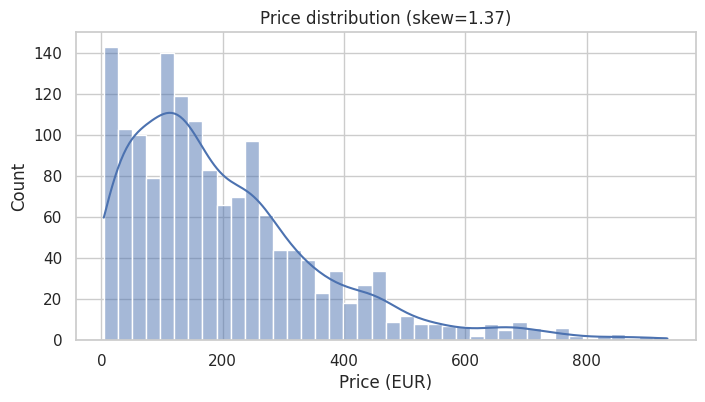

In [46]:
skew_val = df['price'].skew()
plt.figure(figsize=(8, 4))
sns.histplot(df['price'], bins=40, kde=True)
plt.title(f'Price distribution (skew={skew_val:.2f})')
plt.xlabel('Price (EUR)')
plt.show()


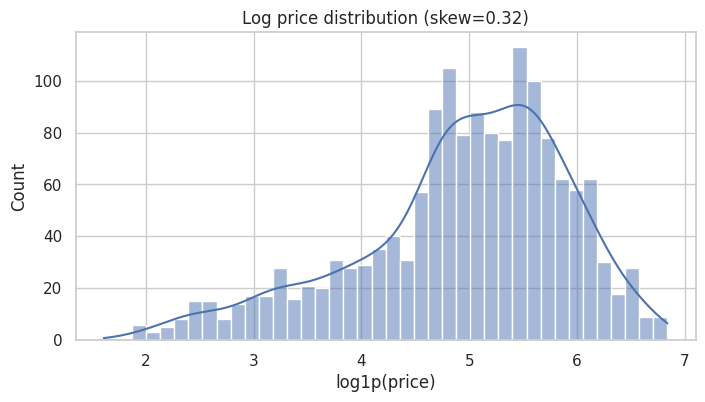

In [47]:
skew_val = np.log(df['price'].skew())

plt.figure(figsize=(8, 4))
sns.histplot(np.log1p(df['price']), bins=40, kde=True)
plt.title('Log price distribution')
plt.title(f'Log price distribution (skew={skew_val:.2f})')

plt.xlabel('log1p(price)')
plt.show()


### 2.1 Price outliers and quantiles


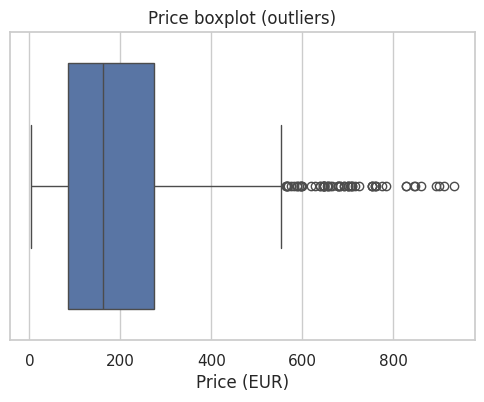

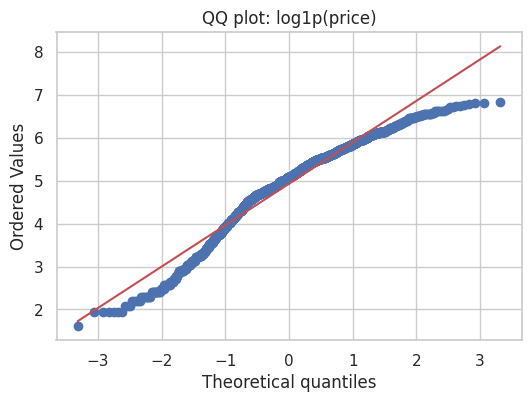

In [48]:
q = df['price'].quantile([0.5, 0.75, 0.95])
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['price'])
plt.title('Price boxplot (outliers)')
plt.xlabel('Price (EUR)')
plt.show()

p95 = df['price'].quantile(0.95)
outlier_pct = (df['price'] > p95).mean() * 100
p95, outlier_pct
import scipy.stats as stats
plt.figure(figsize=(6, 4))
stats.probplot(np.log1p(df['price']), dist='norm', plot=plt)
plt.title('QQ plot: log1p(price)')
plt.show()



### 2.3 Price by product type / brand


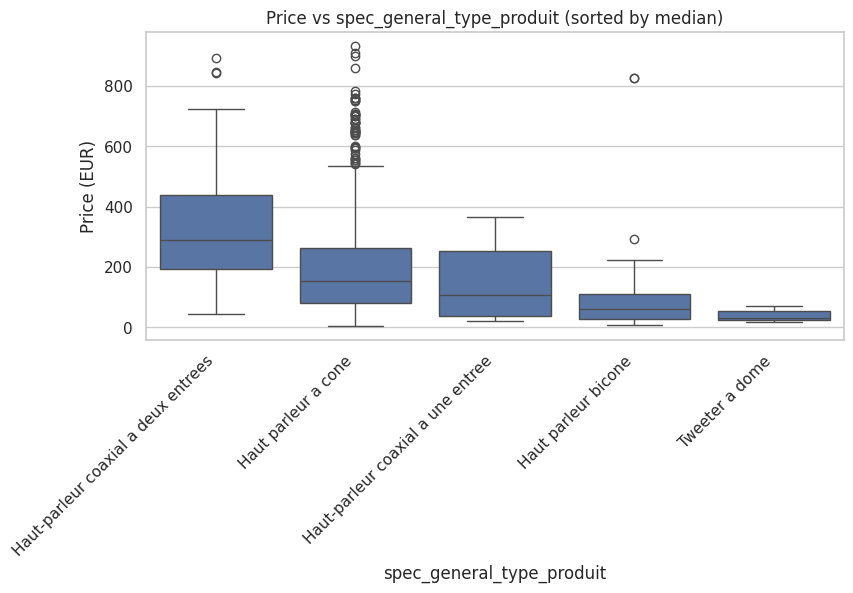

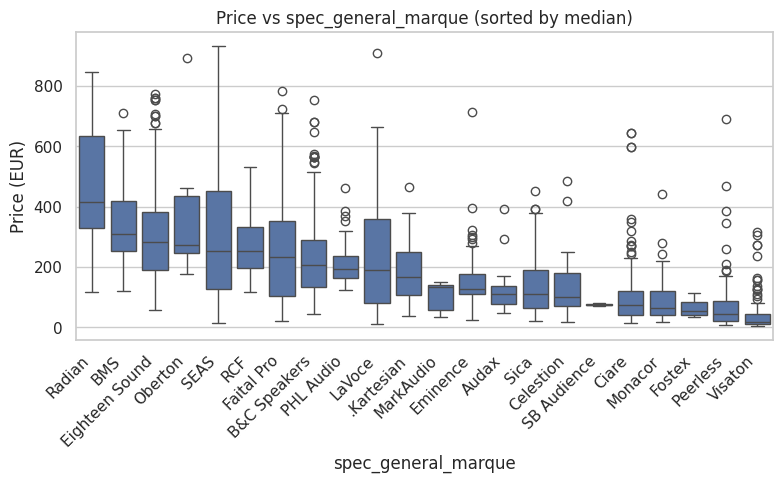

In [49]:
cat_focus = ['spec_general_type_produit', 'spec_general_marque']

for col in cat_focus:
    if col not in df.columns:
        continue

    # Compute median price per category and sort descending
    order = (
        df.groupby(col)['price']
        .median()
        .sort_values(ascending=False)
        .index
    )

    plt.figure(figsize=(9, 4))
    sns.boxplot(
        x=col,
        y='price',
        data=df,
        order=order
    )

    plt.xticks(rotation=45, ha='right')
    plt.title(f'Price vs {col} (sorted by median)')
    plt.xlabel(col)
    plt.ylabel('Price (EUR)')
    plt.show()


  - The raw price is strongly right‑skewed (long tail up to ~900€).
  - Log1p(price) looks much closer to symmetric/normal, which is usually better for linear models and error
    stability.



## 3. Numerical feature analysis


### 3.1 T/S parameters vs price


In [50]:
ts_cols = [
    'spec_parametres_petits_signaux_qts',
    'spec_parametres_petits_signaux_qes',
    'spec_parametres_petits_signaux_qms',
    'spec_parametres_petits_signaux_fs_hz',
    'spec_parametres_fondamentaux_re_ohm',
    'spec_parametres_petits_signaux_vas_l',
    'spec_parametres_fondamentaux_sd_cm2',
]
available_ts_cols = [c for c in ts_cols if c in df.columns]
available_ts_cols


['spec_parametres_petits_signaux_qts',
 'spec_parametres_petits_signaux_qes',
 'spec_parametres_petits_signaux_qms',
 'spec_parametres_petits_signaux_fs_hz',
 'spec_parametres_fondamentaux_re_ohm',
 'spec_parametres_petits_signaux_vas_l',
 'spec_parametres_fondamentaux_sd_cm2']

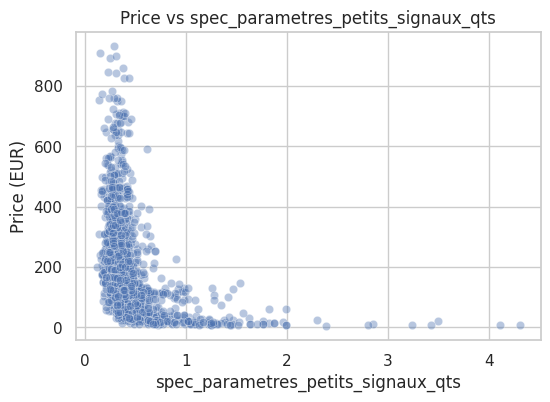

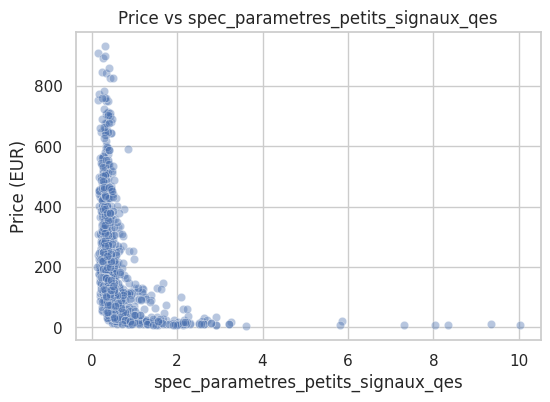

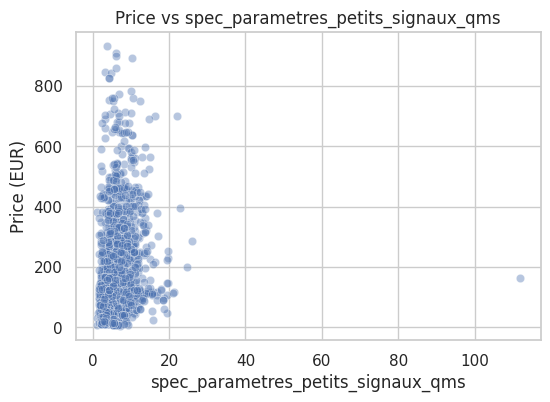

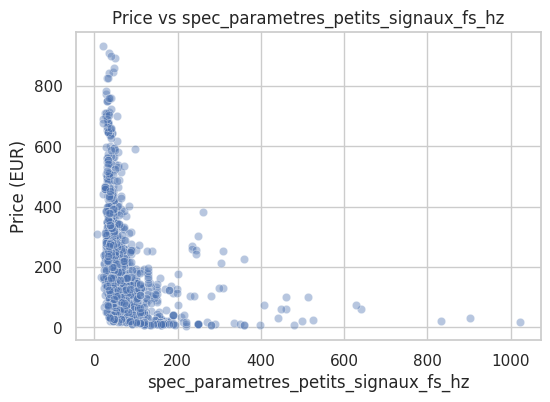

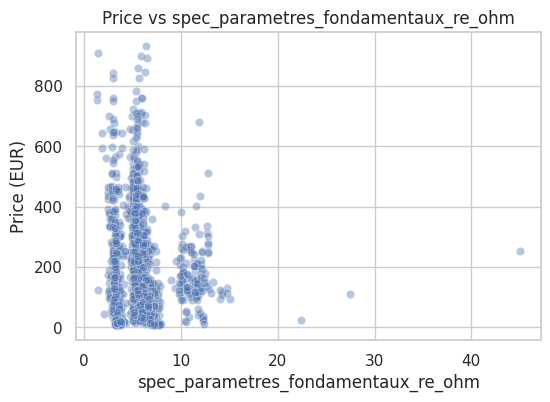

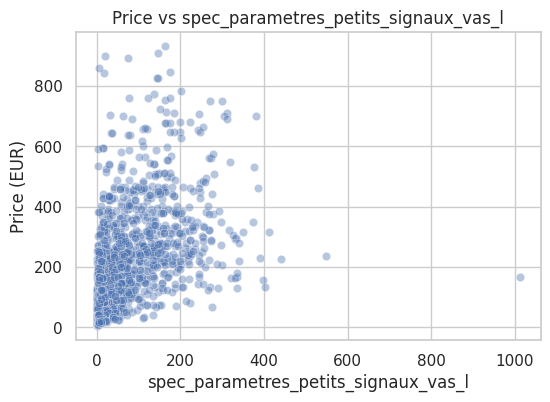

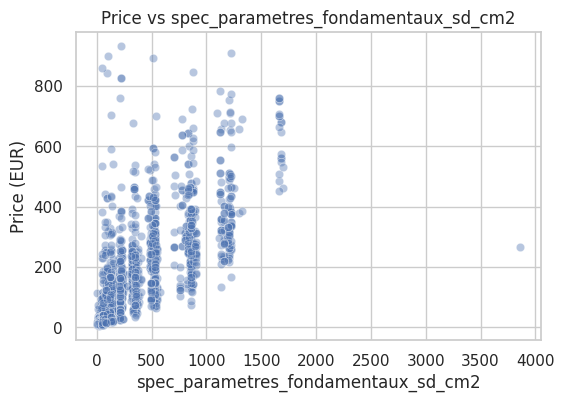

In [51]:
for col in available_ts_cols:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=df[col], y=df['price'], alpha=0.4)
    plt.title(f'Price vs {col}')
    plt.xlabel(col)
    plt.ylabel('Price (EUR)')
    plt.show()


### 3.2 Power, efficiency, and geometry


In [52]:
num_extra = [
    'spec_informations_puissance_nominale_w',
    'spec_informations_puissance_max_w',
    'spec_donnees_rendement_calcule_pct',
    'spec_donnees_rendement_pct',
    'spec_parametres_fondamentaux_bl_t_m',
    'spec_parametres_fondamentaux_mms_gr',
    'spec_parametres_fondamentaux_le_mh',
    'spec_donnees_xmax_mm',
    'spec_dimensions_diametre_systeme_magnetique_mm',
    'spec_dimensions_hauteur_entrefer_mm',
    'spec_dimensions_hauteur_bobinage_mm',
    'spec_donnees_poids_kg',
]
available_extra = [c for c in num_extra if c in df.columns]
available_extra


['spec_informations_puissance_nominale_w',
 'spec_informations_puissance_max_w',
 'spec_donnees_rendement_calcule_pct',
 'spec_donnees_rendement_pct',
 'spec_parametres_fondamentaux_bl_t_m',
 'spec_parametres_fondamentaux_mms_gr',
 'spec_parametres_fondamentaux_le_mh',
 'spec_donnees_xmax_mm',
 'spec_dimensions_diametre_systeme_magnetique_mm',
 'spec_dimensions_hauteur_entrefer_mm',
 'spec_dimensions_hauteur_bobinage_mm',
 'spec_donnees_poids_kg']

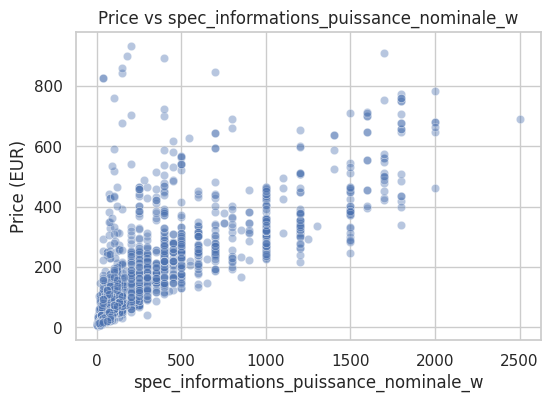

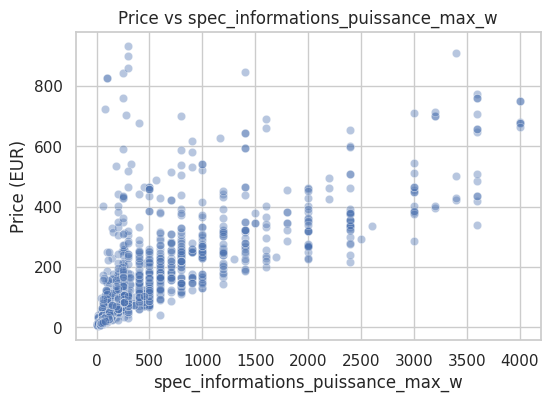

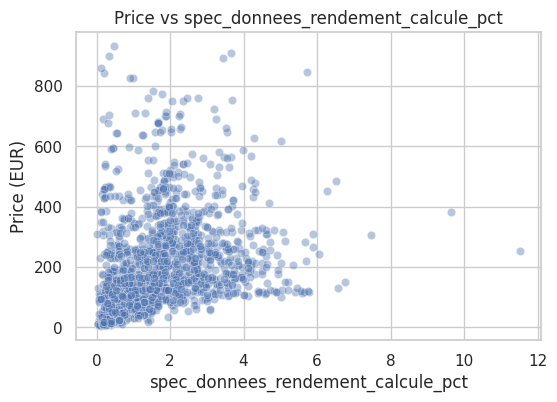

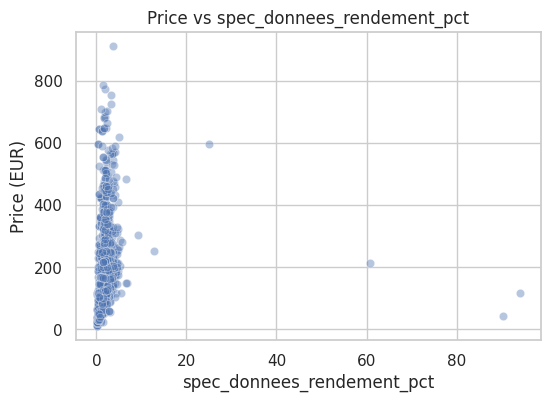

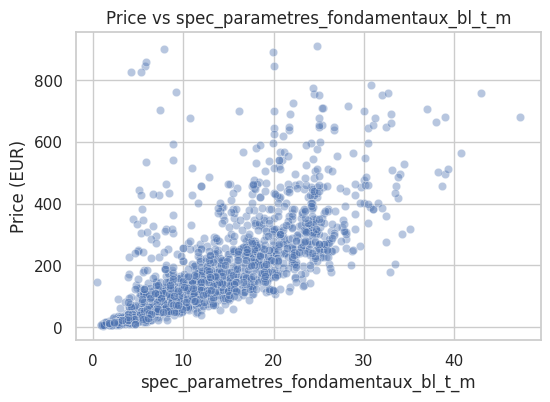

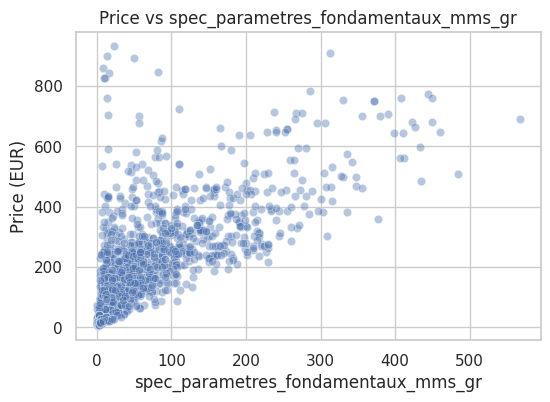

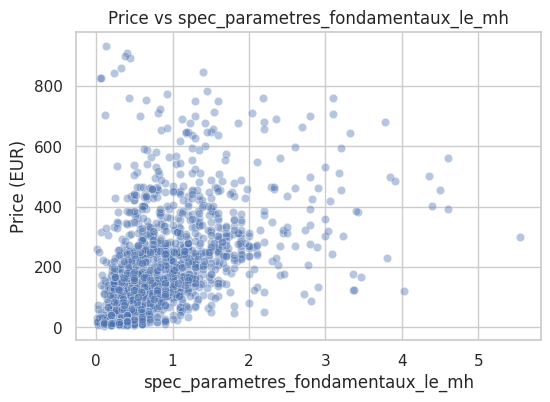

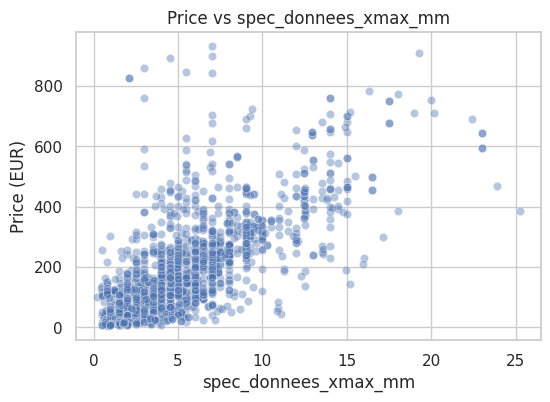

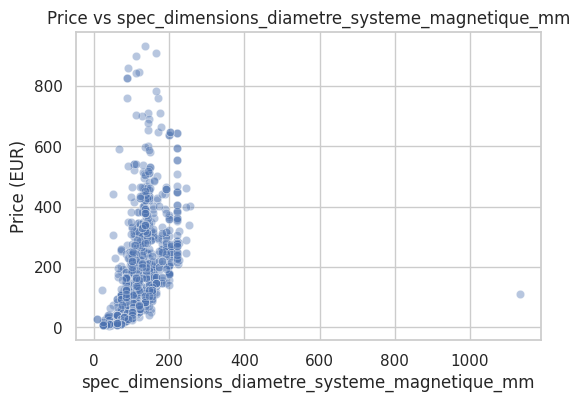

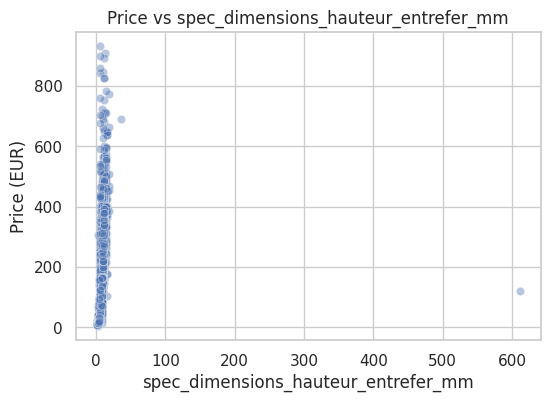

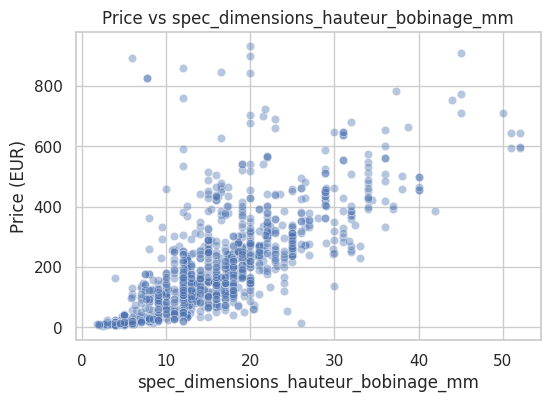

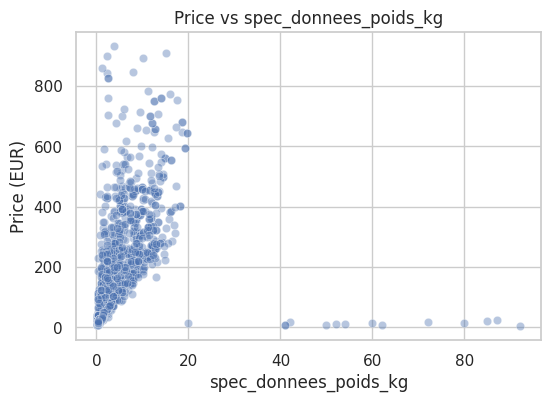

In [53]:
for col in available_extra:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=df[col], y=df['price'], alpha=0.4)
    plt.title(f'Price vs {col}')
    plt.xlabel(col)
    plt.ylabel('Price (EUR)')
    plt.show()


## 4. Categorical feature analysis


In [54]:
cat_cols = [
    'spec_general_marque',
    'spec_general_type_produit',
    'spec_informations_impedance_nominale',
    'spec_forme_materiaux_systeme_magnetique',
    'spec_forme_materiaux_forme_facade',
    'spec_forme_materiaux_materiau_saladier',
    'spec_forme_materiaux_materiau_suspension',
    'spec_forme_materiaux_support_bobine',
    'spec_forme_materiaux_fil_bobine',
    'spec_forme_materiaux_materiau_dome',
]
available_cat = [c for c in cat_cols if c in df.columns]
available_cat


['spec_general_marque',
 'spec_general_type_produit',
 'spec_informations_impedance_nominale',
 'spec_forme_materiaux_systeme_magnetique',
 'spec_forme_materiaux_forme_facade',
 'spec_forme_materiaux_materiau_saladier',
 'spec_forme_materiaux_materiau_suspension',
 'spec_forme_materiaux_support_bobine',
 'spec_forme_materiaux_fil_bobine',
 'spec_forme_materiaux_materiau_dome']

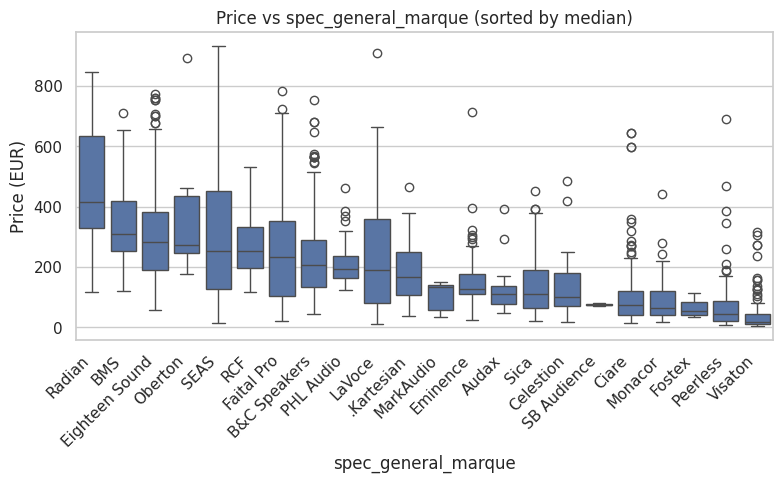

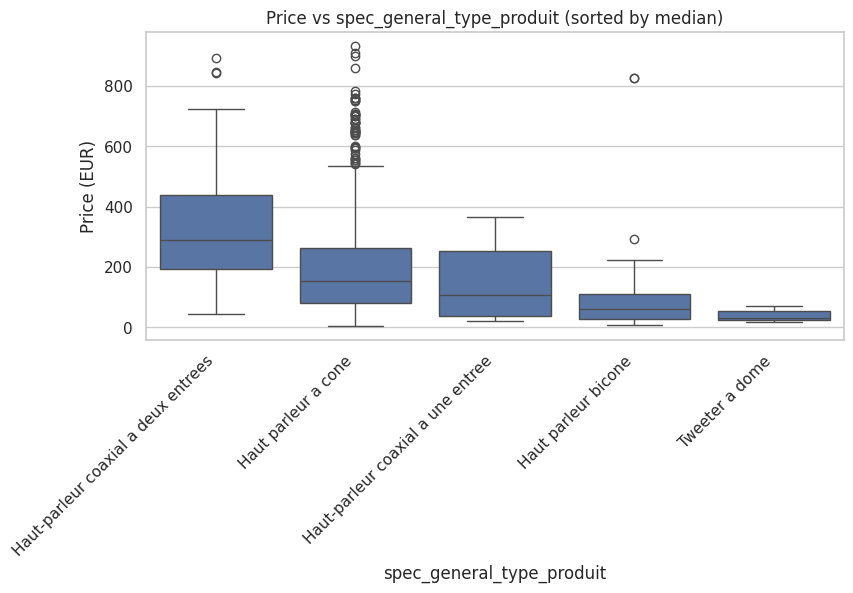

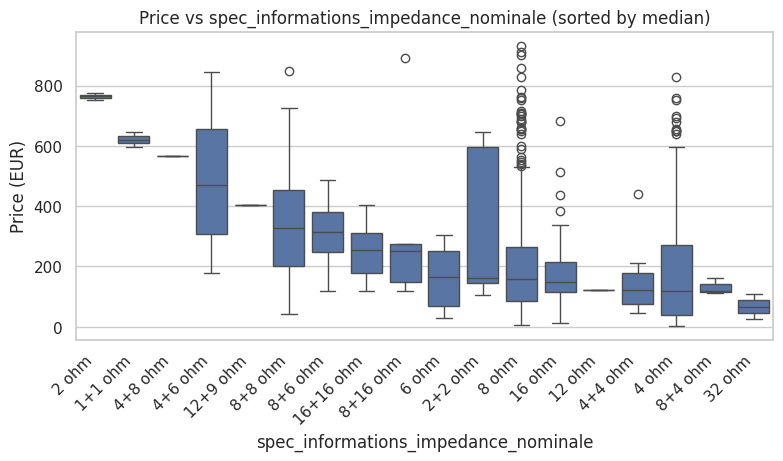

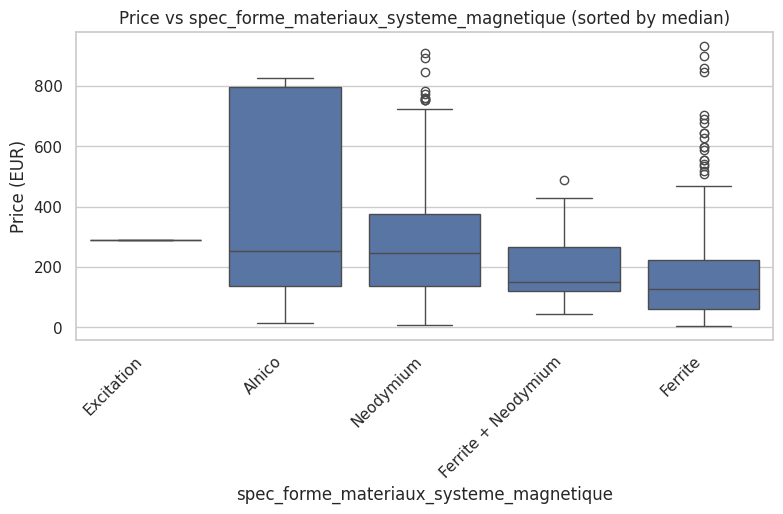

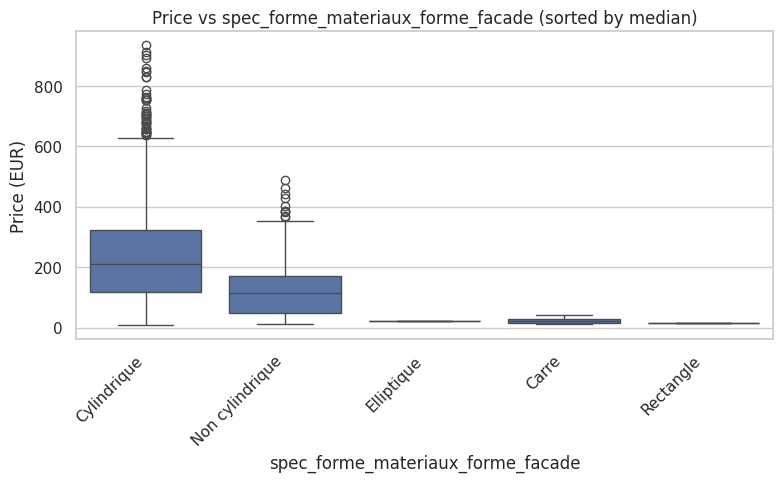

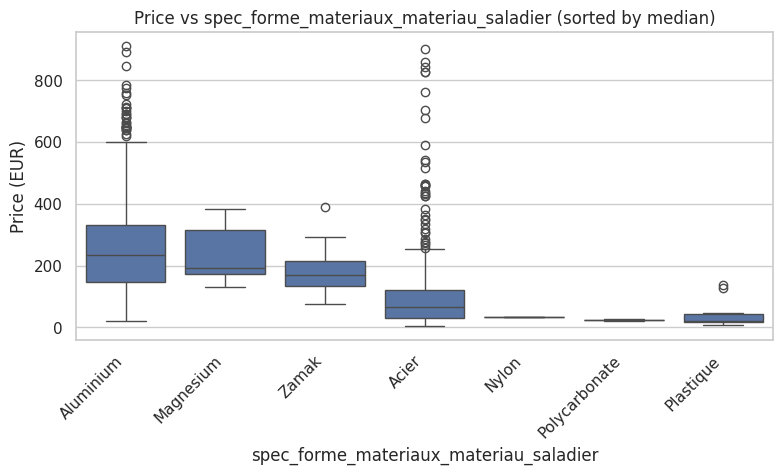

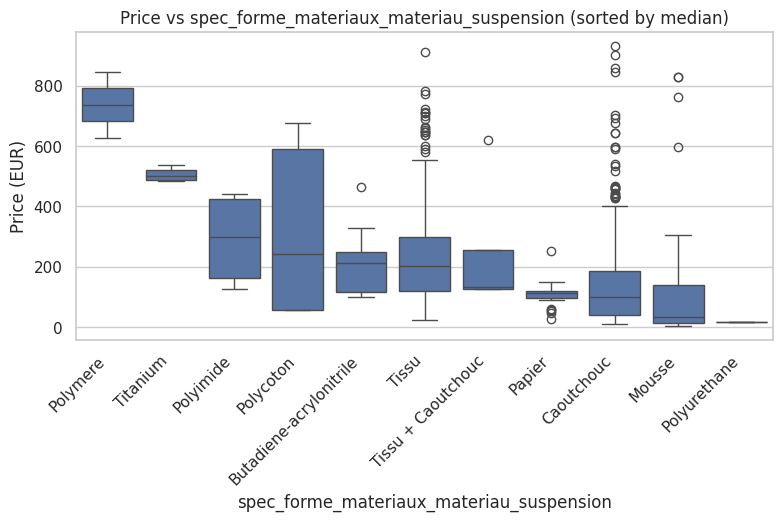

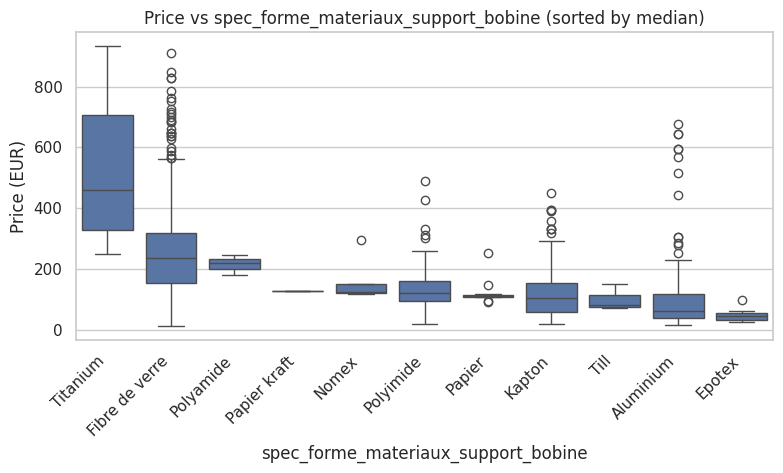

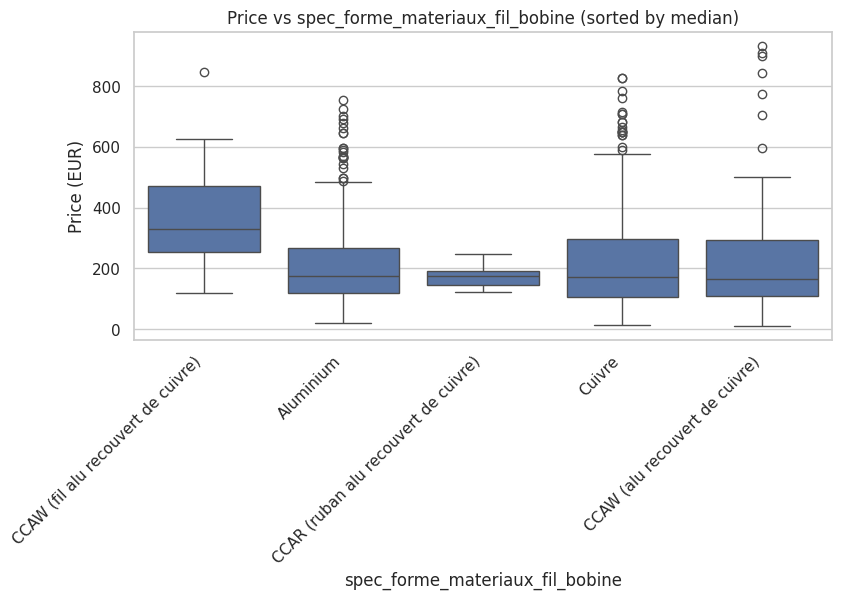

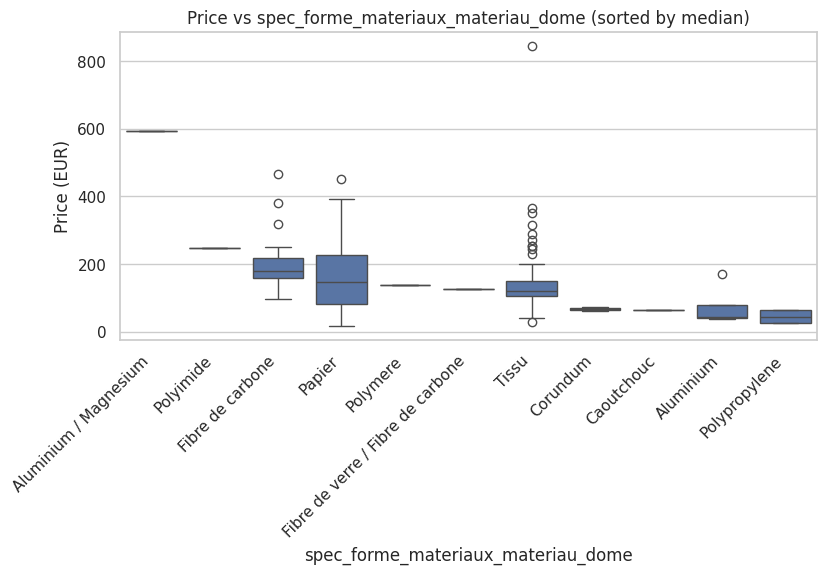

In [55]:
for col in available_cat:
    if col not in df.columns:
        continue

    # Order categories by median price (descending)
    order = (
        df.groupby(col)['price']
        .median()
        .sort_values(ascending=False)
        .index
    )

    plt.figure(figsize=(9, 4))
    sns.boxplot(
        x=col,
        y='price',
        data=df,
        order=order
    )

    plt.xticks(rotation=45, ha='right')
    plt.title(f'Price vs {col} (sorted by median)')
    plt.xlabel(col)
    plt.ylabel('Price (EUR)')
    # plt.tight_layout()
    plt.show()


## 5. Correlation analysis


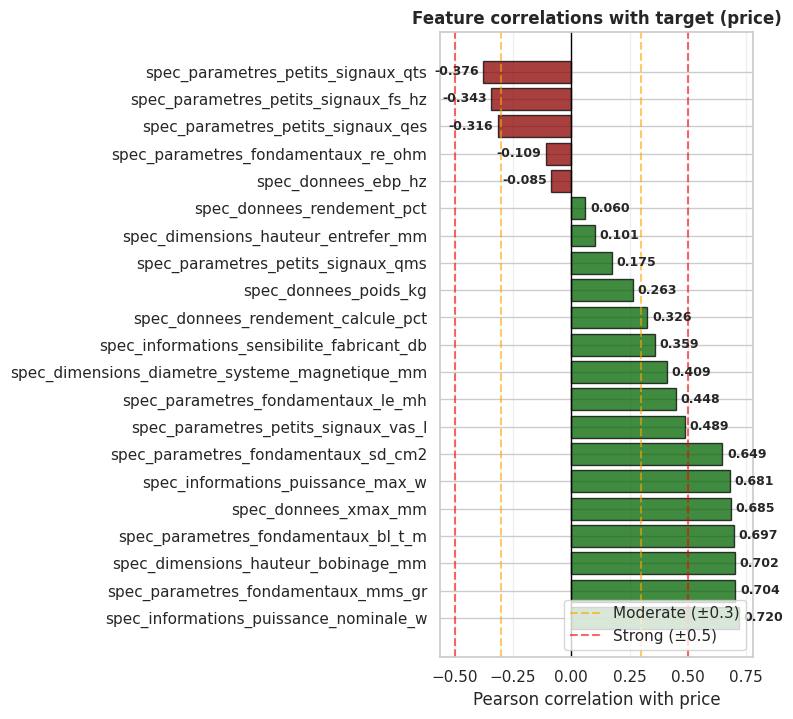


📊 Correlation strength distribution:
Very weak\n(0–0.1)        2
Weak\n(0.1–0.3)           4
Moderate\n(0.3–0.5)       8
Strong\n(0.5–0.7)         4
Very strong\n(0.7–1.0)    3
Name: price, dtype: int64


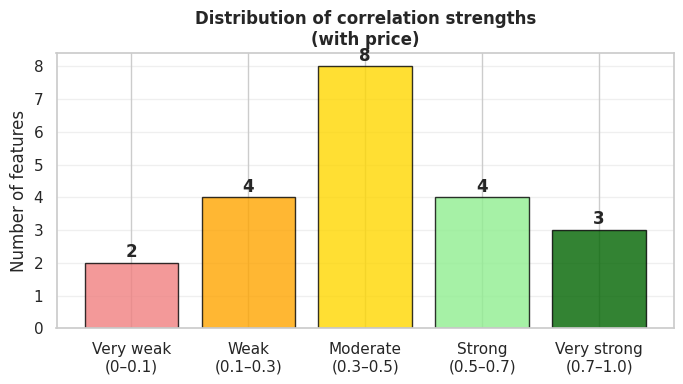

In [66]:
numeric_cols = df.select_dtypes(include=['number']).columns
corr = df[numeric_cols].corr(numeric_only=True)
corr['price'].sort_values(ascending=False)

import matplotlib.pyplot as plt
import numpy as np

target = "price"

# Extract & sort correlations with target
target_corr = (
    corr[target]
    .drop(target)
    .dropna()
    .sort_values(ascending=False)
)



# --- Bar chart ---
plt.figure(figsize=(8, max(4, 0.35 * len(target_corr))))

colors = ["darkgreen" if v > 0 else "darkred" for v in target_corr.values]

bars = plt.barh(
    target_corr.index,
    target_corr.values,
    color=colors,
    edgecolor="black",
    alpha=0.75,
)

plt.axvline(0, color="black", linewidth=1)
plt.axvline(0.3, color="orange", linestyle="--", alpha=0.6, label="Moderate (±0.3)")
plt.axvline(-0.3, color="orange", linestyle="--", alpha=0.6)
plt.axvline(0.5, color="red", linestyle="--", alpha=0.6, label="Strong (±0.5)")
plt.axvline(-0.5, color="red", linestyle="--", alpha=0.6)

# Annotate values
for bar, val in zip(bars, target_corr.values):
    plt.text(
        val + (0.02 if val > 0 else -0.02),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        ha="left" if val > 0 else "right",
        fontsize=9,
        fontweight="bold",
    )

plt.xlabel("Pearson correlation with price")
plt.title("Feature correlations with target (price)", fontweight="bold")
plt.legend(loc="lower right")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

import pandas as pd

abs_corr = target_corr.abs()

bins = [0, 0.1, 0.3, 0.5, 0.7, 1.0]
labels = [
    "Very weak\n(0–0.1)",
    "Weak\n(0.1–0.3)",
    "Moderate\n(0.3–0.5)",
    "Strong\n(0.5–0.7)",
    "Very strong\n(0.7–1.0)",
]

strength_dist = pd.cut(abs_corr, bins=bins, labels=labels).value_counts().sort_index()

print("\n📊 Correlation strength distribution:")
print(strength_dist)

# --- Plot ---
plt.figure(figsize=(7, 4))

colors = ["lightcoral", "orange", "gold", "lightgreen", "darkgreen"]

bars = plt.bar(
    strength_dist.index,
    strength_dist.values,
    color=colors,
    edgecolor="black",
    alpha=0.8,
)

for bar, val in zip(bars, strength_dist.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        str(val),
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.ylabel("Number of features")
plt.title("Distribution of correlation strengths\n(with price)", fontweight="bold")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()



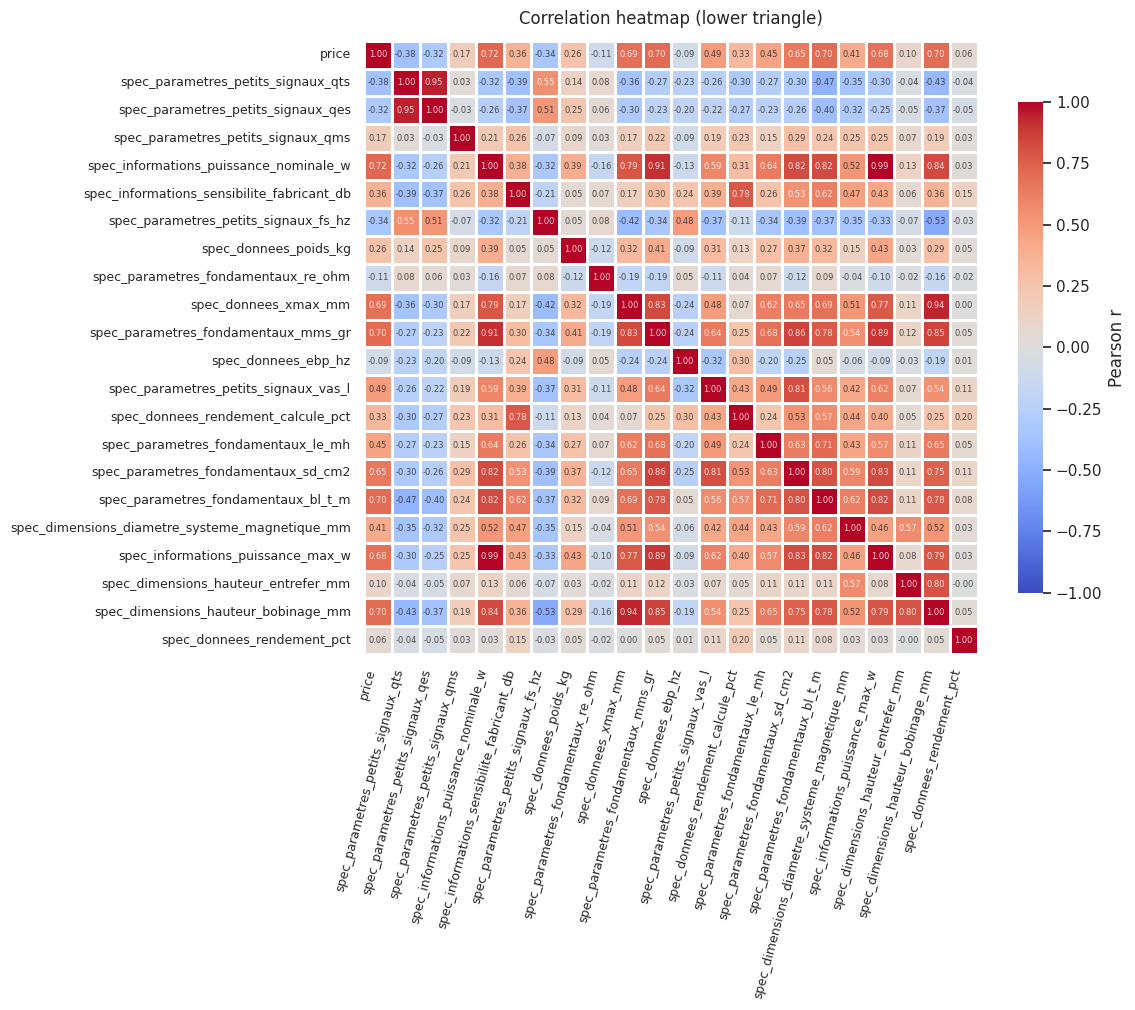

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

ax = sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.8,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6, "alpha": 0.8},
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
)

ax.set_title("Correlation heatmap (lower triangle)", pad=12)
ax.tick_params(axis="x", rotation=60, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=9)
ax.tick_params(axis="x", rotation=75, labelsize=9)
for lbl in ax.get_xticklabels():
    lbl.set_horizontalalignment("right")

plt.tight_layout()
plt.show()


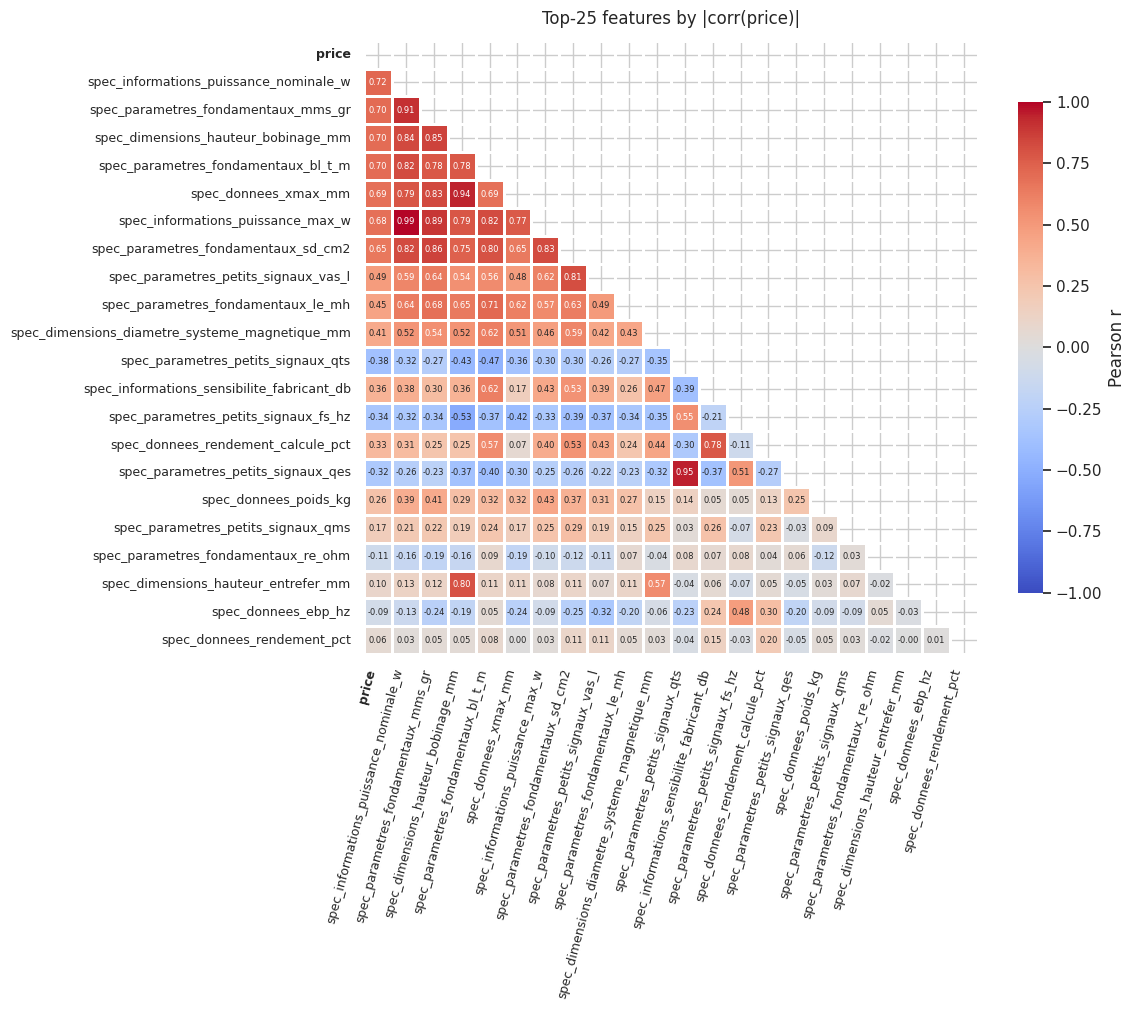

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

target = "price"
k = 25  # take top-K most related to target (edit)

corr_all = corr.copy()
rank = corr_all[target].abs().sort_values(ascending=False)# --- ordering ---
cols = [target] + [
    c for c in rank.index if c != target
][:k-1]
corr_k = corr_all.loc[cols, cols]

# --- plot ---
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_k, dtype=bool), k=0)

ax = sns.heatmap(
    corr_k,
    mask=mask,
    cmap="coolwarm",
    center=0, vmin=-1, vmax=1,
    square=True,
    linewidths=0.8,
    annot=True, fmt=".2f",
    annot_kws={"size": 6},
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
)

ax.set_title(f"Top-{k} features by |corr({target})|", pad=12)
ax.tick_params(axis="x", rotation=75, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=9)

for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
    if label.get_text() == target:
        label.set_fontweight("bold")

for label in ax.get_yticklabels():
    if label.get_text() == target:
        label.set_fontweight("bold")

plt.tight_layout()
plt.show()


This figure shows the **Top-20 numerical features ranked by absolute Pearson correlation with price**, together with their **pairwise correlations** (lower triangle).

Key points to state explicitly in the report:

* Features are **ordered by decreasing |corr(feature, price)|**
* Color encodes the **Pearson correlation coefficient**
* Only the **lower triangle** is shown to avoid redundancy

---

## 2. Main result: price is driven by a dominant latent factor

### 2.1 Strong positive correlations with price

The strongest price-correlated features are:

* Nominal and maximum power (`puissance_nominale_w`, `puissance_max_w`)
* Mechanical and motor parameters (`BL`, `Sd`, `Mms`)
* Excursion and geometry metrics (`Xmax`, coil height, magnetic system diameter)

These features exhibit **Pearson correlations with price in the range ~0.65–0.75**.

### Interpretation (important)

These variables describe **the same physical capability axis**:

> motor strength, excursion capacity, and power handling.

This indicates that **price primarily reflects the size and performance capability of the driver**, rather than isolated tuning parameters.

---

## 3. Strong redundancy among top price drivers

A key insight from the matrix is that **most top price-correlated features are also strongly correlated with each other**:

* Correlations among power, BL, Sd, Mms, Xmax often exceed **0.8–0.9**
* This reveals **severe multicollinearity**

### Implication

Although many variables correlate with price, **they do not represent independent information**.
They encode a **single latent engineering factor**.

This justifies:

* feature pruning
* dimensionality reduction
* or regularized models (e.g. ridge regression)

---

## 4. Secondary effects: control and tuning parameters

Several parameters show **moderate or negative correlations with price**:

* `Qts`, `Qes`, `Fs` are **negatively correlated**
* Sensitivity and efficiency show **moderate positive correlations**

### Interpretation

Higher-priced drivers tend to:

* have **lower resonance frequency**
* exhibit **stronger motor control**
* operate in **tighter, more controlled regimes**

These effects are **secondary**, modulating price rather than driving it.

---

## 5. Weakly correlated variables

Some features show **low or near-zero correlation with price**, such as:

* electrical resistance (`Re`) (which make sens as Re is mostly a standard 4 to 8 omh)
* certain small-signal parameters (ebp, efficiency)

These variables:

* contribute little to explaining price directly
* may still be relevant for **design constraints or application-specific performance**
* but are **poor predictors of price**




## 6. Notes and next steps
 The Pearson correlation analysis reveals that price is predominantly driven by a single latent engineering factor combining motor strength, excursion capability, and power handling. Although multiple specifications exhibit strong correlations with price, these variables are themselves highly correlated, indicating substantial redundancy. Secondary parameters related to small-signal behavior and tuning show weaker or negative correlations. This structure motivates feature pruning or regularization prior to modeling and suggests that price largely reflects overall performance capacity rather than isolated design parameters.



In [85]:
print("\n🎯 Correlations with target (price) to remove:")
print(target_corr.round(3)[abs(target_corr)<0.11])
df = pd.read_csv(data_path)
df = df.drop(columns=["row_id"])
df = df.drop(columns=["spec_general_reference"])
df = df.drop(columns=["spec_dimensions_hauteur_entrefer_mm"])
df = df.drop(columns=["spec_donnees_rendement_pct"])
df = df.drop(columns=["spec_donnees_ebp_hz"])
df = df.drop(columns=["spec_parametres_fondamentaux_re_ohm"])
df.head()

df.columns


🎯 Correlations with target (price) to remove:
spec_dimensions_hauteur_entrefer_mm    0.101
spec_donnees_rendement_pct             0.060
spec_donnees_ebp_hz                   -0.085
spec_parametres_fondamentaux_re_ohm   -0.109
Name: price, dtype: float64


Index(['price', 'spec_general_marque', 'spec_general_type_produit', 'spec_informations_impedance_nominale', 'spec_forme_materiaux_systeme_magnetique', 'spec_forme_materiaux_forme_facade',
       'spec_parametres_petits_signaux_qts', 'spec_parametres_petits_signaux_qes', 'spec_parametres_petits_signaux_qms', 'spec_forme_materiaux_materiau_saladier',
       'spec_forme_materiaux_materiau_suspension', 'spec_forme_materiaux_support_bobine', 'spec_forme_materiaux_fil_bobine', 'spec_forme_materiaux_materiau_dome',
       'spec_informations_puissance_nominale_w', 'spec_informations_sensibilite_fabricant_db', 'spec_parametres_petits_signaux_fs_hz', 'spec_donnees_poids_kg', 'spec_donnees_xmax_mm',
       'spec_parametres_fondamentaux_mms_gr', 'spec_parametres_petits_signaux_vas_l', 'spec_donnees_rendement_calcule_pct', 'spec_parametres_fondamentaux_le_mh',
       'spec_parametres_fondamentaux_sd_cm2', 'spec_parametres_fondamentaux_bl_t_m', 'spec_dimensions_diametre_systeme_magnetique_mm', 'spec